In [6]:
# ============================================================
# AI Innovators Lab: Cat vs Dog Image Classifier
# Goal: Train an AI model that can recognize cats and dogs.
#
# Dataset:
# Upload your reduced CatsVsDogs.zip file.
#
# Expected zip structure:
# CatsVsDogs/
#   PetImages/
#     Cat/
#     Dog/
# ============================================================

print("Welcome to the Cat vs Dog Classifier Project!")
# Display information for the user.
print("Goal: Build a simple AI model that can recognize cats and dogs.")
# Display information for the user.

# ============================================================
# Step 1: Import required libraries
# ============================================================

import os
import zipfile
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from google.colab import files

print("Libraries loaded successfully!")
# Display information for the user.



Welcome to the Cat vs Dog Classifier Project!
Goal: Build a simple AI model that can recognize cats and dogs.
Libraries loaded successfully!


In [7]:
# ============================================================
# Step 2: Upload your CatsVsDogs.zip file
#
# IMPORTANT:
# Upload CatsVsDogs.zip, NOT kaggle.json.
# ============================================================

uploaded = files.upload()
# Ask the user to upload files from their computer.

zip_filename = list(uploaded.keys())[0]
# Save this value in the variable "zip_filename".

print("Uploaded file:", zip_filename)
# Display information for the user.



Saving CatsVsDogs.zip to CatsVsDogs (2).zip
Uploaded file: CatsVsDogs (2).zip


In [8]:
# ============================================================
# Step 3: Extract the zip file
# ============================================================

extract_dir = "uploaded_dataset"
# Save this value in the variable "extract_dir".

if os.path.exists(extract_dir):
# Check whether this folder already exists.
    shutil.rmtree(extract_dir)
    # Delete the old folder so we start fresh.

os.makedirs(extract_dir, exist_ok=True)
# Create this folder if it does not already exist.

with zipfile.ZipFile(zip_filename, "r") as zip_ref:
# Open the uploaded ZIP file so we can read its contents.
    zip_ref.extractall(extract_dir)
    # Extract every file from the ZIP into a folder.

print("Dataset extracted successfully!")
# Display information for the user.



Dataset extracted successfully!


In [9]:
# ============================================================
# Step 4: Find Cat and Dog folders automatically
# ============================================================

cat_dir = None
# Save this value in the variable "cat_dir".
dog_dir = None
# Save this value in the variable "dog_dir".

for root, dirs, file_list in os.walk(extract_dir):
# Look through every folder and subfolder.
    folder_name = os.path.basename(root).lower()
    # Save this value in the variable "folder_name".

    if folder_name == "cat":
    # Check a condition before running the next lines.
        cat_dir = root
        # Save this value in the variable "cat_dir".

    if folder_name == "dog":
    # Check a condition before running the next lines.
        dog_dir = root
        # Save this value in the variable "dog_dir".

print("Cat folder:", cat_dir)
# Display information for the user.
print("Dog folder:", dog_dir)
# Display information for the user.

if cat_dir is None or dog_dir is None:
# Check a condition before running the next lines.
    raise ValueError("Could not find Cat and Dog folders. Please check your zip file structure.")



Cat folder: uploaded_dataset/CatsVsDogs/PetImages/Cat
Dog folder: uploaded_dataset/CatsVsDogs/PetImages/Dog


In [10]:
# ============================================================
# Step 5: Create clean train and validation folders
#
# We ignore Mac system files such as __MACOSX and .DS_Store.
# ============================================================

base_dir = "cat_dog_ready"
# Save this value in the variable "base_dir".

if os.path.exists(base_dir):
# Check whether this folder already exists.
    shutil.rmtree(base_dir)
    # Delete the old folder so we start fresh.

for split in ["train", "validation"]:
# Repeat these steps for every item.
    for label in ["cat", "dog"]:
    # Repeat these steps for every item.
        os.makedirs(os.path.join(base_dir, split, label), exist_ok=True)
        # Create this folder if it does not already exist.

image_extensions = (".jpg", ".jpeg", ".png")
# Save this value in the variable "image_extensions".

cat_images = [
# Save this value in the variable "cat_images".
    os.path.join(cat_dir, f)
    for f in os.listdir(cat_dir)
    # Repeat these steps for every item.
    if f.lower().endswith(image_extensions) and not f.startswith("._")
    # Check a condition before running the next lines.
]

dog_images = [
# Save this value in the variable "dog_images".
    os.path.join(dog_dir, f)
    for f in os.listdir(dog_dir)
    # Repeat these steps for every item.
    if f.lower().endswith(image_extensions) and not f.startswith("._")
    # Check a condition before running the next lines.
]

random.shuffle(cat_images)
random.shuffle(dog_images)

print("Total cat images:", len(cat_images))
# Display information for the user.
print("Total dog images:", len(dog_images))
# Display information for the user.

# Use 80% for training and 20% for validation
def split_images(image_list):
    split_index = int(len(image_list) * 0.8)
    # Save this value in the variable "split_index".
    return image_list[:split_index], image_list[split_index:]

cat_train, cat_val = split_images(cat_images)
# Save this value in the variable "cat_train, cat_val".
dog_train, dog_val = split_images(dog_images)
# Save this value in the variable "dog_train, dog_val".

def copy_images(image_paths, destination_folder):
    for i, img_path in enumerate(image_paths):
    # Repeat these steps for every item.
        ext = os.path.splitext(img_path)[1]
        # Save this value in the variable "ext".
        new_name = f"image_{i}{ext}"
        # Save this value in the variable "new_name".
        shutil.copy(img_path, os.path.join(destination_folder, new_name))

copy_images(cat_train, os.path.join(base_dir, "train", "cat"))
copy_images(cat_val, os.path.join(base_dir, "validation", "cat"))

copy_images(dog_train, os.path.join(base_dir, "train", "dog"))
copy_images(dog_val, os.path.join(base_dir, "validation", "dog"))

train_dir = os.path.join(base_dir, "train")
# Save this value in the variable "train_dir".
validation_dir = os.path.join(base_dir, "validation")
# Save this value in the variable "validation_dir".

print("Clean dataset prepared successfully!")
# Display information for the user.

print("Training cats:", len(os.listdir(os.path.join(train_dir, "cat"))))
# Display information for the user.
print("Training dogs:", len(os.listdir(os.path.join(train_dir, "dog"))))
# Display information for the user.
print("Validation cats:", len(os.listdir(os.path.join(validation_dir, "cat"))))
# Display information for the user.
print("Validation dogs:", len(os.listdir(os.path.join(validation_dir, "dog"))))
# Display information for the user.



Total cat images: 751
Total dog images: 601
Clean dataset prepared successfully!
Training cats: 600
Training dogs: 480
Validation cats: 151
Validation dogs: 121


In [11]:
# ============================================================
# Step 6: Remove corrupted images, if any
# ============================================================

from PIL import Image

def remove_bad_images(folder):
    removed = 0
    # Save this value in the variable "removed".

    for root, dirs, files_list in os.walk(folder):
    # Look through every folder and subfolder.
        for file_name in files_list:
        # Repeat these steps for every item.
            file_path = os.path.join(root, file_name)
            # Save this value in the variable "file_path".

            try:
                img = Image.open(file_path)
                # Open the image file.
                img.verify()
            except Exception:
                os.remove(file_path)
                removed += 1
                # Save this value in the variable "removed +".

    return removed

removed_train = remove_bad_images(train_dir)
# Save this value in the variable "removed_train".
removed_validation = remove_bad_images(validation_dir)
# Save this value in the variable "removed_validation".

print("Bad training images removed:", removed_train)
# Display information for the user.
print("Bad validation images removed:", removed_validation)
# Display information for the user.



Bad training images removed: 1
Bad validation images removed: 0


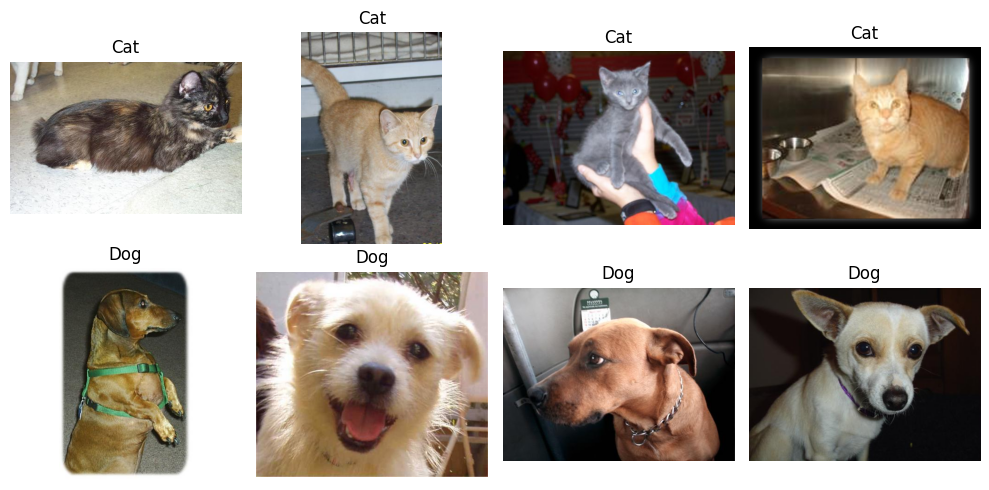

In [12]:
# ============================================================
# Step 7: Show sample images
# ============================================================

cat_sample_folder = os.path.join(train_dir, "cat")
# Save this value in the variable "cat_sample_folder".
dog_sample_folder = os.path.join(train_dir, "dog")
# Save this value in the variable "dog_sample_folder".

cat_samples = os.listdir(cat_sample_folder)[:4]
# Save this value in the variable "cat_samples".
dog_samples = os.listdir(dog_sample_folder)[:4]
# Save this value in the variable "dog_samples".

plt.figure(figsize=(10, 5))
# Save this value in the variable "plt.figure(figsize".

for i, img_name in enumerate(cat_samples):
# Repeat these steps for every item.
    img_path = os.path.join(cat_sample_folder, img_name)
    # Save this value in the variable "img_path".
    img = plt.imread(img_path)
    # Save this value in the variable "img".

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title("Cat")
    plt.axis("off")

for i, img_name in enumerate(dog_samples):
# Repeat these steps for every item.
    img_path = os.path.join(dog_sample_folder, img_name)
    # Save this value in the variable "img_path".
    img = plt.imread(img_path)
    # Save this value in the variable "img".

    plt.subplot(2, 4, i + 5)
    plt.imshow(img)
    plt.title("Dog")
    plt.axis("off")

plt.tight_layout()
plt.show()



In [13]:
# ============================================================
# Step 8: Load images for training
# ============================================================

IMG_SIZE = 150
# Save this value in the variable "IMG_SIZE".
BATCH_SIZE = 32
# Save this value in the variable "BATCH_SIZE".

train_dataset = tf.keras.utils.image_dataset_from_directory(
# Load images from folders and automatically assign labels.
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    # Save this value in the variable "image_size".
    batch_size=BATCH_SIZE,
    # Save this value in the variable "batch_size".
    label_mode="binary"
    # Save this value in the variable "label_mode".
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
# Load images from folders and automatically assign labels.
    validation_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    # Save this value in the variable "image_size".
    batch_size=BATCH_SIZE,
    # Save this value in the variable "batch_size".
    label_mode="binary"
    # Save this value in the variable "label_mode".
)

class_names = train_dataset.class_names
# Save this value in the variable "class_names".

print("Class names:", class_names)
# Display information for the user.

# Improve performance
AUTOTUNE = tf.data.AUTOTUNE
# Save this value in the variable "AUTOTUNE".

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
# Save this value in the variable "train_dataset".
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)
# Save this value in the variable "validation_dataset".



Found 1079 files belonging to 2 classes.
Found 272 files belonging to 2 classes.
Class names: ['cat', 'dog']


In [14]:
# ============================================================
# Step 9: Build the AI model
# ============================================================

model = models.Sequential([
# Create a neural network by stacking layers in order.
    layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    # Save this value in the variable "layers.Rescaling(1./255, input_shape".

    layers.Conv2D(32, (3, 3), activation="relu"),
    # Find useful patterns such as edges and shapes in images.
    layers.MaxPooling2D(2, 2),
    # Reduce image size while keeping important features.

    layers.Conv2D(64, (3, 3), activation="relu"),
    # Find useful patterns such as edges and shapes in images.
    layers.MaxPooling2D(2, 2),
    # Reduce image size while keeping important features.

    layers.Conv2D(128, (3, 3), activation="relu"),
    # Find useful patterns such as edges and shapes in images.
    layers.MaxPooling2D(2, 2),
    # Reduce image size while keeping important features.

    layers.Flatten(),
    # Convert the feature maps into a single list of numbers.
    layers.Dense(128, activation="relu"),
    # Learn how to make the final prediction.
    layers.Dropout(0.5),
    # Randomly ignore some neurons during training to reduce overfitting.

    layers.Dense(1, activation="sigmoid")
    # Learn how to make the final prediction.
])

model.compile(
# Tell TensorFlow how the model should learn.
    optimizer="adam",
    # Save this value in the variable "optimizer".
    loss="binary_crossentropy",
    # Save this value in the variable "loss".
    metrics=["accuracy"]
    # Save this value in the variable "metrics".
)

model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# ============================================================
# Step 10: Train the model
# ============================================================

history = model.fit(
# Train the model using the training images.
    train_dataset,
    epochs=5,
    # Save this value in the variable "epochs".
    validation_data=validation_dataset
    # Save this value in the variable "validation_data".
)

print("Model training completed!")
# Display information for the user.



Epoch 1/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.5255 - loss: 0.7324 - val_accuracy: 0.6066 - val_loss: 0.6887
Epoch 2/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.5746 - loss: 0.6827 - val_accuracy: 0.5735 - val_loss: 0.6808
Epoch 3/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.6006 - loss: 0.6627 - val_accuracy: 0.6029 - val_loss: 0.6747
Epoch 4/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.6284 - loss: 0.6522 - val_accuracy: 0.6176 - val_loss: 0.6584
Epoch 5/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.6877 - loss: 0.6130 - val_accuracy: 0.6765 - val_loss: 0.6010
Model training completed!


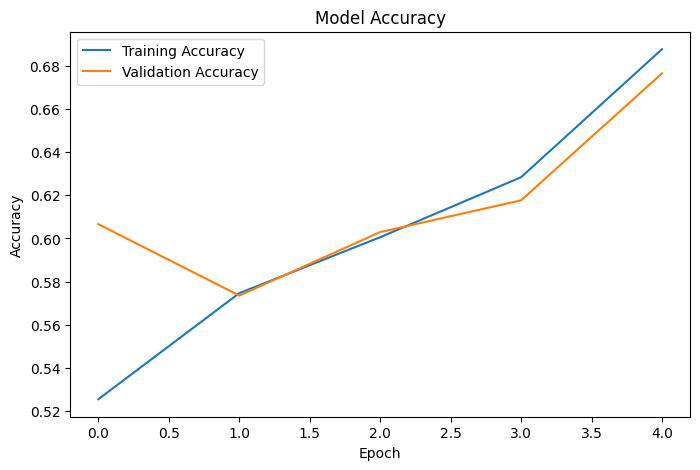

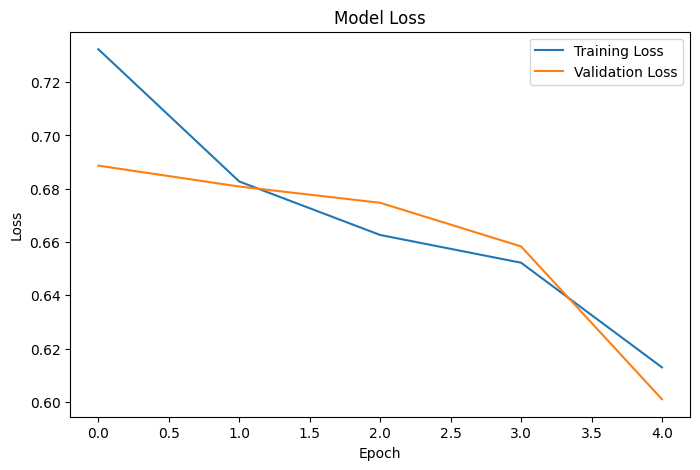

In [16]:
# ============================================================
# Step 11: Plot accuracy and loss
# ============================================================

plt.figure(figsize=(8, 5))
# Save this value in the variable "plt.figure(figsize".
plt.plot(history.history["accuracy"], label="Training Accuracy")
# Draw a graph so we can see how the model performed.
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
# Draw a graph so we can see how the model performed.
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
# Save this value in the variable "plt.figure(figsize".
plt.plot(history.history["loss"], label="Training Loss")
# Draw a graph so we can see how the model performed.
plt.plot(history.history["val_loss"], label="Validation Loss")
# Draw a graph so we can see how the model performed.
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()



Saving 116.jpg to 116.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


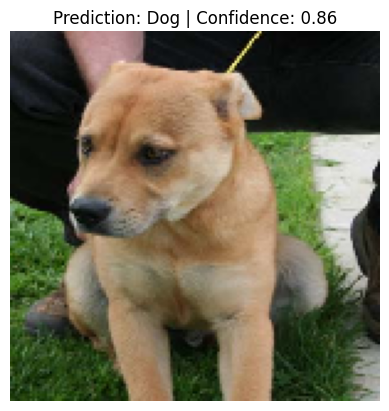

The AI thinks this is a: Dog
Confidence: 86.2 %


In [21]:
# ============================================================
# Step 12: Upload your own cat or dog image
# ============================================================

uploaded_test = files.upload()
# Ask the user to upload files from their computer.

for filename in uploaded_test.keys():
# Repeat these steps for every item.
    img_path = filename
    # Save this value in the variable "img_path".

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    # Save this value in the variable "img".
    img_array = image.img_to_array(img)
    # Convert the image into numbers that the computer can process.
    img_array = np.expand_dims(img_array, axis=0)
    # Add one extra dimension because the model expects a batch of images.

    prediction = model.predict(img_array)[0][0]
    # Ask the trained model to make a prediction.

    plt.imshow(img)
    plt.axis("off")

    if prediction > 0.5:
    # Check a condition before running the next lines.
        predicted_label = "Dog"
        # Save this value in the variable "predicted_label".
        confidence = prediction
        # Save this value in the variable "confidence".
    else:
        predicted_label = "Cat"
        # Save this value in the variable "predicted_label".
        confidence = 1 - prediction
        # Save this value in the variable "confidence".

    plt.title(f"Prediction: {predicted_label} | Confidence: {confidence:.2f}")
    plt.show()

    print("The AI thinks this is a:", predicted_label)
    # Display information for the user.
    print("Confidence:", round(confidence * 100, 2), "%")
    # Display information for the user.



In [22]:
# ============================================================
# Step 13: Save the trained model
# ============================================================

model.save("cat_dog_classifier_model.h5")
# Save the trained AI model so it can be used later.

print("Model saved as cat_dog_classifier_model.h5")
# Display information for the user.



Model saved as cat_dog_classifier_model.h5


In [23]:
# ============================================================
# Step 14: Reflection questions for final showcase
# ============================================================

reflection_questions = [
# Save this value in the variable "reflection_questions".
    "1. What problem does your AI model solve?",
    "2. What dataset did you use?",
    "3. What are the two classes your model predicts?",
    "4. How did the AI learn from cat and dog images?",
    "5. What was your model accuracy?",
    "6. Did the model make any mistakes?",
    "7. Why might some images be hard to classify?",
    "8. How could this type of AI be used in real life?"
]

print("\nReflection Questions:")
# Display information for the user.
for question in reflection_questions:
# Repeat these steps for every item.
    print(question)    # Display information for the user.



Reflection Questions:
1. What problem does your AI model solve?
2. What dataset did you use?
3. What are the two classes your model predicts?
4. How did the AI learn from cat and dog images?
5. What was your model accuracy?
6. Did the model make any mistakes?
7. Why might some images be hard to classify?
8. How could this type of AI be used in real life?


# ============================================================
# Presentation Template for Students
# ============================================================

presentation_template = """
Project Title:
Cat vs Dog Image Classifier

Team Members:
[Names]

Problem:
We wanted to build an AI model that can tell whether an image is a cat or a dog.

Dataset:
We used a reduced CatsVsDogs image dataset.

Input:
Image of a cat or dog

Prediction:
Cat or Dog

Model Used:
Convolutional Neural Network (CNN)

Result:
Our model reached approximately ____% validation accuracy.

Demo:
We uploaded a new image and the model predicted whether it was a cat or dog.

What We Learned:
We learned how AI can classify images using training data.

Future Improvement:
We could train with more images, use better image quality, or improve the model.
"""

print(presentation_template)